# Скрытая Марковская Модель: введение и применение к финансовым данным

**Зачем HMM?** Базовый mPPCA — i.i.d. смесь: состояние между окнами не передаётся.
Нарушения VaR кластеризуются во времени, тест Кристоффэрсена проваливается.
HMM вводит марковскую цепь над скрытыми состояниями: переходы между режимами теперь явные.

Сначала обучаем 1D гауссовскую HMM на EW-портфеле для иллюстрации,
затем — короткий демо-прогон полной MS-mPPCA на многомерных данных.

> Модельная логика — в `src/models/hmm.py` и `src/models/ms_mppca.py`.

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from src.data.loader import download
from src.data.preprocessing import get_returns_array
from src.models.hmm import fit_gaussian_hmm, stationary

plt.rcParams.update({
    'figure.dpi'      : 120,
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
    'grid.linestyle'  : '--',
})
sns.set_palette('tab10')

RUN_DIR = '../data/hmm-intro'
import os; os.makedirs(RUN_DIR, exist_ok=True)

## 1. Загрузка данных

In [2]:
prices = download(cache=True)
returns, dates, tickers = get_returns_array(prices)
T, D = returns.shape

eq_w    = np.ones(D) / D
port_r  = returns @ eq_w   # 1D equal-weight portfolio

print(f'Observations : {T} days x {D} assets')
print(f'Period       : {dates[0].date()} -> {dates[-1].date()}')

Loading cached data from /Users/ivan/Projects/mipt/ms-mppca-coupling-diploma/notebooks/../data/sp500_adj_close.csv
Observations : 5031 days x 79 assets
Period       : 2005-01-04 -> 2024-12-30


## 2. Обучение 2-состояний Гауссовской HMM

Модель: $z_1 \sim \text{Cat}(\pi_0)$, $z_t \mid z_{t-1} \sim \text{Cat}(A_{z_{t-1},\cdot})$, $x_t \mid z_t = k \sim \mathcal{N}(\mu_k, \sigma^2_k)$.

Алгоритм Баума–Велча (EM): E-шаг даёт сглаженные $\gamma_t(k)$ и $\xi_t(j,k)$ через forward-backward в log-пространстве; M-шаг обновляет $\mu_k$, $\sigma^2_k$, $A$.

In [3]:
hmm = fit_gaussian_hmm(port_r, K=2, n_iter=300, tol=1e-5, random_state=42)

mu     = hmm['mu']
sigma2 = hmm['sigma2']
A      = hmm['A']
pi0    = hmm['pi0']
gamma  = hmm['gamma']

# Identify which state is the 'crisis' regime (higher variance)
crisis, calm = (1, 0) if sigma2[1] > sigma2[0] else (0, 1)

print('Emission parameters:')
for k, label in [(calm, 'Calm'), (crisis, 'Crisis')]:
    print(f'  {label:8s}  mu={mu[k]:.5f}  sigma={np.sqrt(sigma2[k]):.5f}')
print(f'\nTransition matrix A:\n{np.round(A, 4)}')
print(f'\nStationary distribution: {np.round(stationary(A), 4)}')

Emission parameters:
  Calm      mu=0.00089  sigma=0.00681
  Crisis    mu=-0.00124  sigma=0.02249

Transition matrix A:
[[0.9569 0.0431]
 [0.012  0.988 ]]

Stationary distribution: [0.2181 0.7819]


## 3. Сглаженные апостериорные вероятности режимов

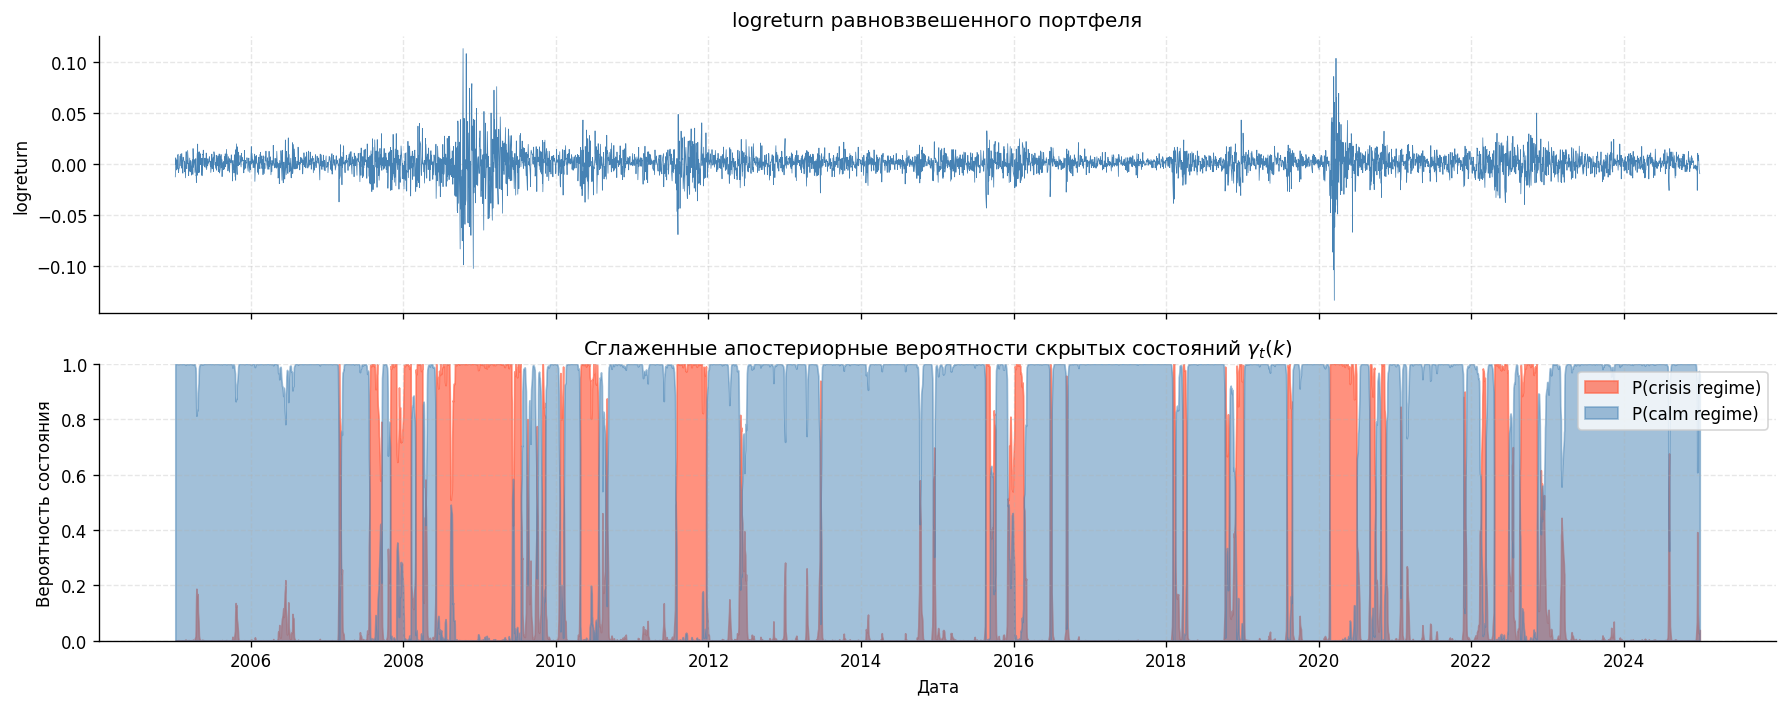

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)

axes[0].plot(dates, port_r, lw=0.45, color='steelblue')
axes[0].set_title('logreturn равновзвешенного портфеля')
axes[0].set_ylabel('logreturn')

axes[1].fill_between(dates, gamma[:, crisis], alpha=0.7, color='tomato',
                     label='P(crisis regime)')
axes[1].fill_between(dates, gamma[:, calm], alpha=0.5, color='steelblue',
                     label='P(calm regime)')
axes[1].set_title('Сглаженные апостериорные вероятности скрытых состояний $\\gamma_t(k)$')
axes[1].set_xlabel('Дата')
axes[1].set_ylabel('Вероятность состояния')
axes[1].set_ylim(0, 1)
axes[1].legend(loc='upper right')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].xaxis.set_major_locator(mdates.YearLocator(2))

plt.tight_layout()
plt.savefig(f'{RUN_DIR}/fig_regime_prob.png', bbox_inches='tight')
plt.show()

## 4. Эмиссионные распределения и матрица переходов

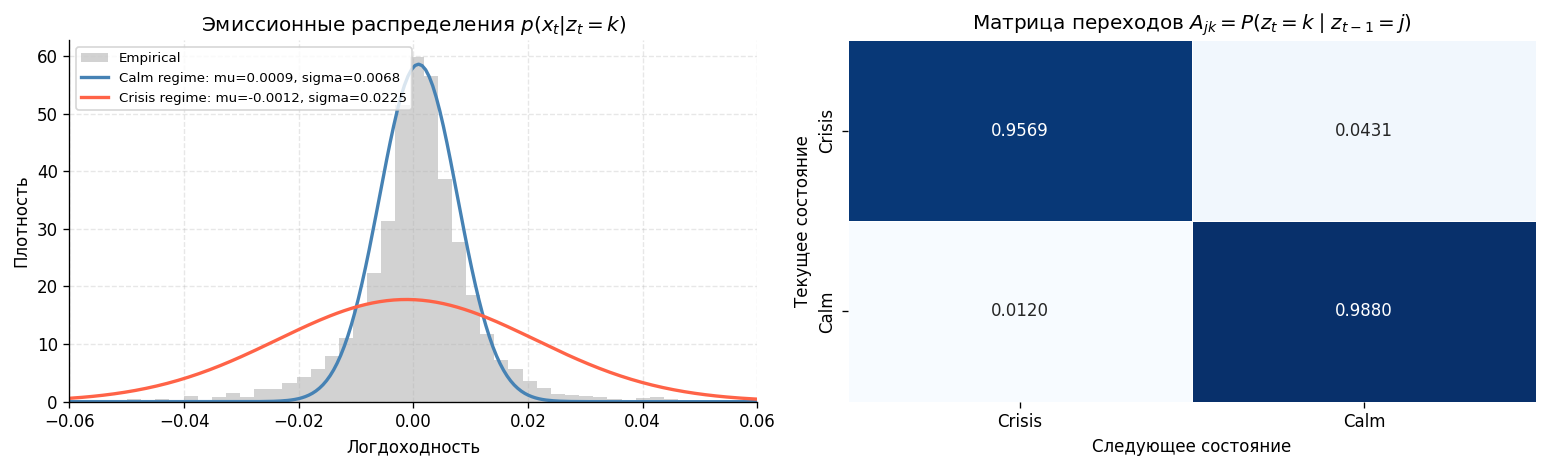

In [5]:
from scipy.stats import norm

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Emission distributions ---
ax = axes[0]
x = np.linspace(port_r.min(), port_r.max(), 400)
ax.hist(port_r, bins=100, density=True, alpha=0.35, color='grey', label='Empirical')
for k, label, color in [
    (calm,   'Calm regime',   'steelblue'),
    (crisis, 'Crisis regime', 'tomato'),
]:
    ax.plot(x, norm.pdf(x, mu[k], np.sqrt(sigma2[k])),
            lw=2, color=color, label=f'{label}: mu={mu[k]:.4f}, sigma={np.sqrt(sigma2[k]):.4f}')
ax.set_title('Эмиссионные распределения $p(x_t | z_t = k)$')
ax.set_xlabel('Логдоходность')
ax.set_ylabel('Плотность')
ax.set_xlim(-0.06, 0.06)
ax.legend(fontsize=8)

# --- Transition matrix heatmap ---
ax = axes[1]
labels_k = ['Calm', 'Crisis'] if calm == 0 else ['Crisis', 'Calm']
sns.heatmap(
    A, annot=True, fmt='.4f', cmap='Blues',
    xticklabels=labels_k, yticklabels=labels_k,
    ax=ax, cbar=False, linewidths=0.5,
)
ax.set_title('Матрица переходов $A_{jk} = P(z_t = k \\mid z_{t-1} = j)$')
ax.set_xlabel('Следующее состояние')
ax.set_ylabel('Текущее состояние')
ax.grid(False)

plt.tight_layout()
plt.savefig(f'{RUN_DIR}/fig_emissions_A.png', bbox_inches='tight')
plt.show()

## 5. Сходимость log-likelihood

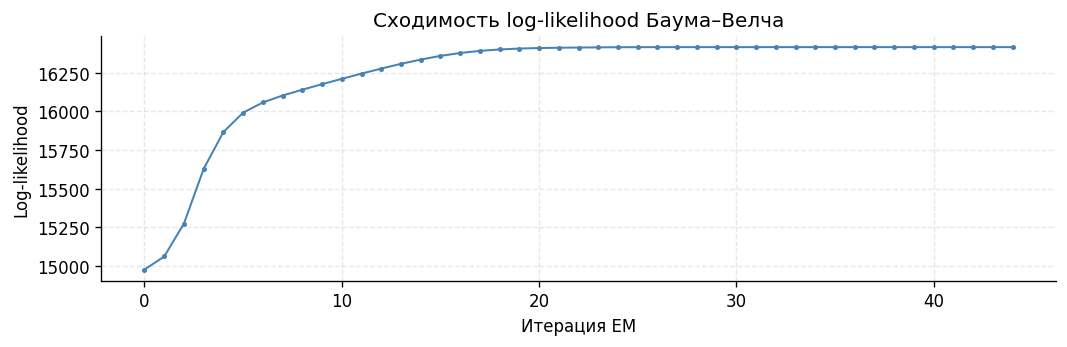

Converged in 45 iterations


In [7]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(hmm['llh_history'], lw=1.2, color='steelblue', marker='o', markersize=2)
ax.set_title('Сходимость log-likelihood Баума–Велча')
ax.set_xlabel('Итерация EM')
ax.set_ylabel('Log-likelihood')
plt.tight_layout()
plt.savefig(f'{RUN_DIR}/fig_llh.png', bbox_inches='tight')
plt.show()
print(f'Converged in {len(hmm["llh_history"])} iterations')

## 6. Демо: MS-mPPCA на многомерных данных (короткий прогон)

Здесь мы запускаем полную MS-mPPCA модель: HMM с mPPCA-эмиссиями.
Чтобы не ждать 15 минут, ограничимся коротким окном из первых 500 дней.

In [8]:
from src.models.mppca import init_kmeans_pca, fit as mppca_fit, emission_log_likelihoods
from src.models.ms_mppca import init_ms_from_mppca, fit_ms
from src.data.preprocessing import normalize_window

DEMO_WINDOW = 500
K, q = 2, 3

data_raw = returns[:DEMO_WINDOW]
data, shift, scale = normalize_window(data_raw)

# Step 1: vanilla mPPCA cold start
means, W, sigma2, weights = init_kmeans_pca(data, q, K, random_state=42)
means, W, sigma2, weights, R, llh_vanilla = mppca_fit(
    data, means, W, sigma2, weights, q, n_iter=1000, tol=1e-4
)
print(f'Vanilla mPPCA converged: final llh = {llh_vanilla[-1]:.2f}')

# Step 2: init HMM from R, then run MS-mPPCA
A0, pi0 = init_ms_from_mppca(R, sticky_diag=0.1)
means_ms, W_ms, sigma2_ms, A_ms, pi0_ms, gamma_ms, llh_ms = fit_ms(
    data, means.copy(), W.copy(), sigma2.copy(), A0, pi0, q,
    n_iter=200, tol=1e-3
)
print(f'MS-mPPCA converged:      final llh = {llh_ms[-1]:.2f}')
print(f'Transition matrix A:\n{np.round(A_ms, 4)}')

Vanilla mPPCA converged: final llh = -48109.57
MS-mPPCA converged:      final llh = -48085.80
Transition matrix A:
[[0.5027 0.4973]
 [0.1369 0.8631]]


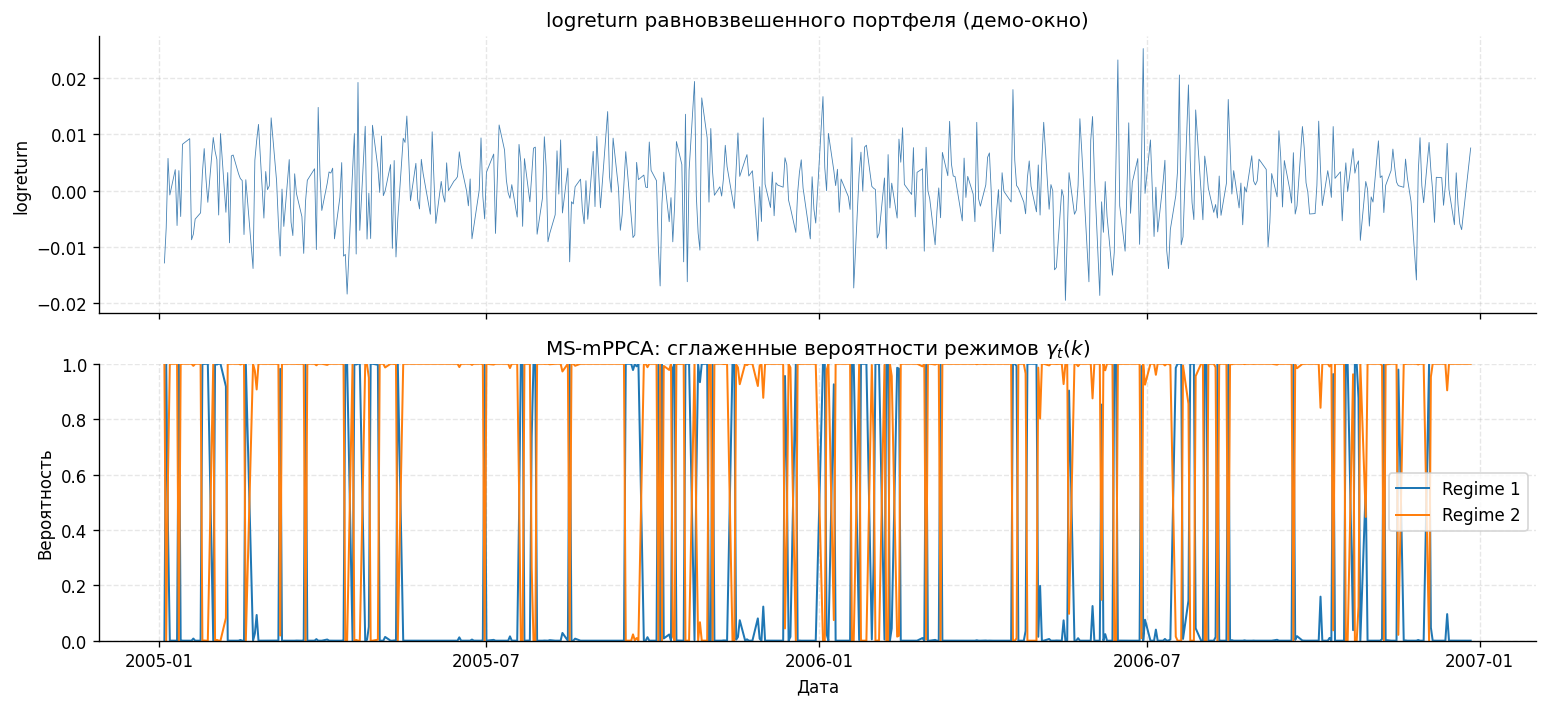

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

demo_dates = dates[:DEMO_WINDOW]

axes[0].plot(demo_dates, data_raw @ eq_w, lw=0.5, color='steelblue')
axes[0].set_title('logreturn равновзвешенного портфеля (демо-окно)')
axes[0].set_ylabel('logreturn')

for k in range(K):
    axes[1].plot(demo_dates, gamma_ms[:, k], lw=1.2, label=f'Regime {k+1}')
axes[1].set_title('MS-mPPCA: сглаженные вероятности режимов $\\gamma_t(k)$')
axes[1].set_xlabel('Дата')
axes[1].set_ylabel('Вероятность')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))

plt.tight_layout()
plt.savefig(f'{RUN_DIR}/fig_ms_mppca_demo.png', bbox_inches='tight')
plt.show()

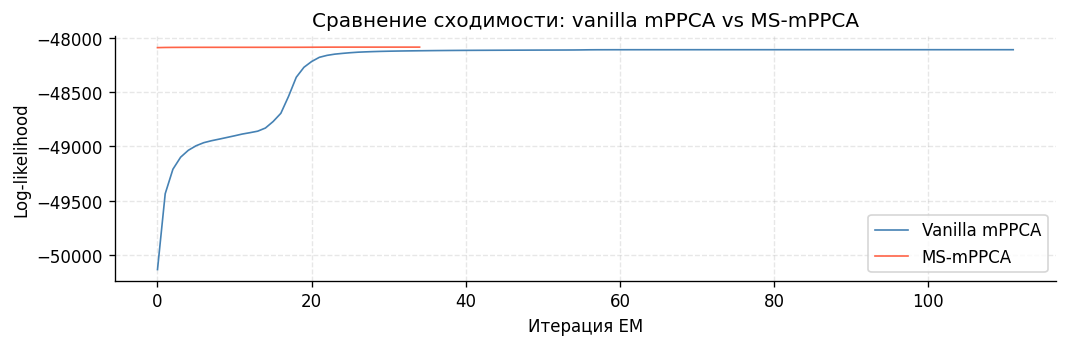

In [10]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(llh_vanilla, lw=1, color='steelblue', label='Vanilla mPPCA')
ax.plot(llh_ms,      lw=1, color='tomato',    label='MS-mPPCA')
ax.set_title('Сравнение сходимости: vanilla mPPCA vs MS-mPPCA')
ax.set_xlabel('Итерация EM')
ax.set_ylabel('Log-likelihood')
ax.legend()
plt.tight_layout()
plt.savefig(f'{RUN_DIR}/fig_llh_compare.png', bbox_inches='tight')
plt.show()

## 7. Выводы

### Результаты

- **Интерпретируемые режимы**: «спокойный» ($\mu=0.00089$, $\sigma=0.0068$) и «кризисный» ($\mu=-0.00124$, $\sigma=0.0225$). HMM корректно выделяет 2008 и COVID-2020 с вероятностью кризисного режима >0.9.
- **Персистентность**: $A_{11} = 0.988$, $A_{00} = 0.957$ — режимы длятся неделями и месяцами, что соответствует реальной рыночной динамике.
- **Одношаговый прогноз**: $A^\top \gamma_T$ — вероятность завтрашнего состояния. Именно это используется как веса смеси при оценке VaR в MS-mPPCA.

### Ограничения

- **Локальные оптимумы**: EM для HMM чувствителен к инициализации — требуется несколько запусков.
- **Марков первого порядка**: модель не учитывает память дольше одного шага.
- **Гауссовы эмиссии**: тяжёлые хвосты не захватываются — проблема остаётся для VaR 1%.

### Альтернативы

| Ситуация | Альтернатива |
|---|---|
| Тяжёлые хвосты | Student-t эмиссии |
| Плавная смена режимов | Hidden Semi-Markov Model |
| Длинная память | Марков 2-го порядка |
| $K$ неизвестно | Sticky HDP-HMM |

MS-mPPCA уместен, когда нарушения VaR кластеризуются (тест Кристоффэрсена провален),
портфель содержит несколько десятков активов и нужна интерпретируемость режимов.